In [1]:
#Carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split


# Importamos las librerias de redes neuronales con sus principales métodos
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Cargar el conjunto de datos de iris
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [3]:
!pip install skimpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.10.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.10.0 which is incompatible.


In [4]:
from skimpy import skim
iris.species= iris.species.astype("category")
skim(iris)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 150    │ │ float64     │ 4     │ │ species               │                                │
│ │ Number of columns │ 5      │ │ category    │ 1     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column            ┃ NA   ┃ NA %   ┃ mean     ┃ sd        ┃ p0    ┃ p25   ┃ p50    ┃ p75  ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ sepal_length      │    0 │      0 │    5.843 │    0.8281 │   4.3 │   5.1 │    5.8 │  6.4 │   7.9 │ ▃██▇▅▂  │  │
│ │ sepal_width       │    0 │      0 │    3.057 │    0.4359 │     2 │   2.8 │      3 │  3.3 │   4.4 │ ▁▇█▇▂▁  │  │
│ │ petal_length      │    0 │      0 │    3.758 │     1.765 │     1 │   1.6 │   4.35 │  5.1 │   6.9 │ █ ▂▇▆▂  │  │
│ │ petal_width       │    0 │      0 │    1.199 │    0.7622 │   0.1 │   0.3 │    1.3 │  1.8 │   2.5 │ █ ▂▆▄▄  │  │
│ └───────────────────┴──────┴────────┴──────────┴───────────┴───────┴───────┴────────┴──────┴───────┴─────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                   ┃ NA         ┃ NA %             ┃ ordered                  ┃ unique               ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ species                  │          0 │                0 │ False                    │                    3 │  │
│ └──────────────────────────┴────────────┴──────────────────┴──────────────────────────┴──────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [5]:
# Separar las características (X) y las etiquetas (y)
X = iris.drop('species', axis=1)
y = iris['species']
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
y.head()

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa


In [7]:
from sklearn.preprocessing import LabelEncoder


# Crear el codificador de etiquetas
label_encoder = LabelEncoder()

# Aplicar el codificador a la variable objetivo "species"
y = label_encoder.fit_transform(y)

In [8]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [9]:
# las redes neuronales son muy sensibles a datos no escalados
scaler_labels = StandardScaler()
X= scaler_labels.fit_transform(X)

In [11]:
#Separo los datos de "train" en entrenamiento y prueba "test" para probar los algoritmos
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
#Defino la función neuronal
def define_model():

    keras.backend.clear_session()
    # se eliminan todos los modelos y operaciones creados en la sesión actual, libera memoria y permita una construcción en limpio
    model = keras.models.Sequential()
    # se utiliza para crear un modelo secuencial en deep learning. Un modelo secuencial es una pila de capas donde la salida de una capa es la entrada de la siguiente capa.

     # 2 capas ocultas con función de activación relu
    model.add(keras.layers.Dense(8, input_dim=4, kernel_initializer='normal', activation='relu'))
    model.add(keras.layers.Dense(4, kernel_initializer='normal', activation='relu'))
    #capa de salida
    model.add(keras.layers.Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], learning_rate=0.001)
    return model

In [14]:
model = define_model()

#Early es un buen metodo de regularizacion, en patience aplicamos un 30 para que al menos tengan que pasar 30 epoch antes de hacer una parada.
early = keras.callbacks.EarlyStopping(patience=30, monitor='val_loss', restore_best_weights=True)
history = model.fit(epochs=300, batch_size=32, x=x_train, y=y_train, validation_data=(x_test, y_test), callbacks=[early])

Epoch 1/300


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.3714 - loss: 1.0986 - val_accuracy: 0.2889 - val_loss: 1.0973
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3524 - loss: 1.0972 - val_accuracy: 0.2667 - val_loss: 1.0964
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3619 - loss: 1.0958 - val_accuracy: 0.3111 - val_loss: 1.0953
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3810 - loss: 1.0945 - val_accuracy: 0.3111 - val_loss: 1.0941
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4667 - loss: 1.0932 - val_accuracy: 0.3333 - val_loss: 1.0925
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5143 - loss: 1.0914 - val_accuracy: 0.5111 - val_loss: 1.0903
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6952 - loss: 1.0893 - val_accuracy: 0.7556 - val_loss: 1.0876
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7714 - loss: 1.0869 - val_accuracy: 0.8000 - val_loss: 1.0847
Epoc

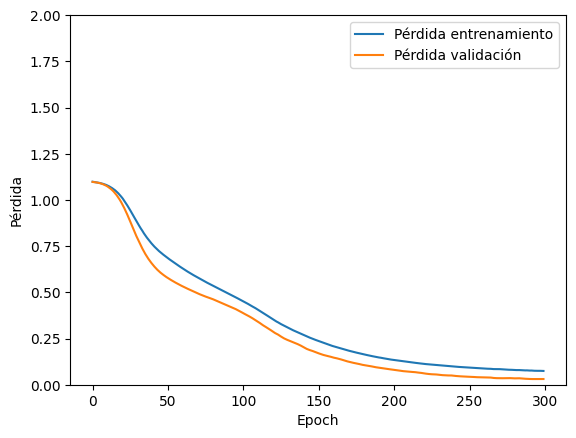

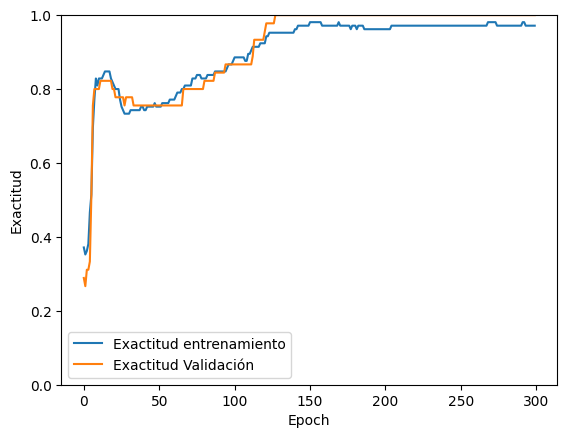

In [16]:
# EVALUACIÓN DEL MODELO

def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Pérdida')
    plt.plot(hist['epoch'], hist['loss'],
           label='Pérdida entrenamiento')
    plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Pérdida validación')
    plt.ylim([0,2])
    plt.legend()

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Exactitud')
    plt.plot(hist['epoch'], hist['accuracy'],
           label='Exactitud entrenamiento')
    plt.plot(hist['epoch'], hist['val_accuracy'],
           label = 'Exactitud Validación')
    plt.ylim([0,1])
    plt.legend()
    plt.show()


plot_history(history)

# una buena red es aquella donde la función de perdida en test y train es baja


In [17]:
# Predicciones sobre TEST (datos que el modelo no vio en el entrenamiento)
y_pred = model.predict(x_test)
y_pred_c = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


In [18]:
y_pred

array([[2.89497077e-02, 9.64858234e-01, 6.19196380e-03],
       [9.99114871e-01, 8.85001209e-04, 1.51810664e-09],
       [1.20880672e-04, 1.61854041e-04, 9.99717236e-01],
       [4.93925288e-02, 9.06815469e-01, 4.37918343e-02],
       [3.59522328e-02, 9.37119961e-01, 2.69278903e-02],
       [9.95687127e-01, 4.31289803e-03, 1.40907197e-08],
       [5.79080060e-02, 9.40709174e-01, 1.38276804e-03],
       [1.59466825e-03, 3.35152494e-03, 9.95053709e-01],
       [5.01662940e-02, 6.98948026e-01, 2.50885606e-01],
       [1.88232455e-02, 9.79354262e-01, 1.82238058e-03],
       [1.13968076e-02, 4.86888252e-02, 9.39914405e-01],
       [9.95036185e-01, 4.96386550e-03, 1.04642091e-08],
       [9.98227239e-01, 1.77285750e-03, 1.73277681e-09],
       [9.96039808e-01, 3.96027416e-03, 8.13485102e-09],
       [9.99877214e-01, 1.22869751e-04, 3.24692856e-10],
       [4.49404567e-02, 9.41573441e-01, 1.34858927e-02],
       [1.12564757e-03, 2.15160032e-03, 9.96722817e-01],
       [1.81612913e-02, 9.80085

In [19]:
y_pred_c

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

In [20]:
from sklearn.metrics import classification_report

# Reporte de clasificación sobre TEST: así medimos generalización, no memorización
classification_summary = classification_report(y_test, y_pred_c)
print(classification_summary)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [21]:
cm = confusion_matrix(y_test, y_pred_c)

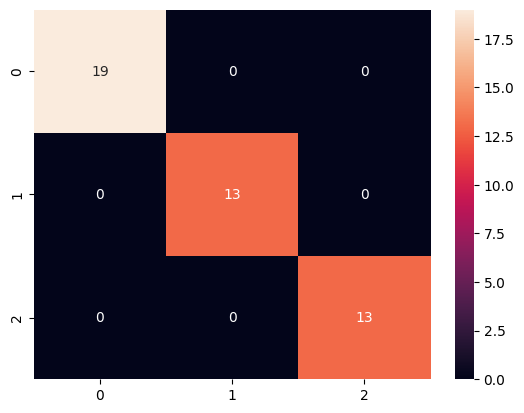

In [22]:
sns.heatmap(cm,annot=True)
plt.savefig('h.png')